---
### O que este dashboard mostra?

Quatro visões complementares dos dados limpos:

1. **Faturamento por Categoria** — quais produtos geram mais receita
2. **Faixas de Ticket** — como se distribui o valor das compras
3. **Formas de Pagamento** — qual o método preferido dos clientes
4. **Faturamento Mensal** — tendência ao longo do tempo

### Por que isso importa?

Este é o ponto de chegada de toda a semana: você partiu de um dado bruto, com problemas de qualidade, e chegou a um dashboard limpo e informativo. Esse é exatamente o fluxo real de trabalho de um analista de dados.

## Exercício de Revisão — Semana 06

Este exercício integra todos os tópicos da semana. Use a base `base_vendas_supermercado.xlsx`.

### Cenário
Você foi contratado para analisar as vendas do supermercado. O arquivo chegou com problemas e você precisa limpá-lo antes de entregar o relatório ao gerente.

### Passos

1. **Carregue** a base e crie uma versão suja:
   - Insira 10 NaN em `'Categoria'` e 8 NaN em `'Quantidade'`
   - Insira 5 valores absurdos em `'Valor Líquido'` (ex: R$ 5000, R$ 0.01)
   - Duplique 7 linhas aleatórias

2. **Diagnóstico**: exiba um relatório com:
   - % de NaN por coluna
   - Número de duplicatas
   - Limites IQR para `'Valor Líquido'` (inferior e superior)

3. **Limpeza completa**:
   - Remova duplicatas
   - Preencha NaN de `'Categoria'` com a moda
   - Preencha NaN de `'Quantidade'` com a mediana
   - Remova outliers de `'Valor Líquido'` pelo método IQR

4. **Transformações**:
   - Crie a coluna `'Mes_Nome'` com o nome do mês (ex: "January")
   - Crie a coluna `'Perfil_Compra'` com `pd.cut()` em 3 faixas de `'Valor Líquido'`
   - Crie a coluna `'Tem_Desconto'` com `np.where()`

5. **Enriquecimento**:
   - Crie uma tabela de metas mensais por loja (defina valores à sua escolha)
   - Faça um `merge` do resumo mensal de vendas com essa tabela de metas
   - Identifique quais lojas atingiram a meta em cada mês

6. **Relatório final**: plote um gráfico mostrando o total de vendas por loja e mês.

## Gabarito — Resumo dos Pontos Principais

### Passo 1 — Criando dados sujos
```python
np.random.seed(42)
df_raw = df.copy()
for col, n in [('Categoria', 10), ('Quantidade', 8)]:
    idx = np.random.choice(df_raw.index, n, replace=False)
    df_raw.loc[idx, col] = np.nan
idx_out = np.random.choice(df_raw.index, 5, replace=False)
df_raw.loc[idx_out[:3], 'Valor Líquido'] = [5000, 4500, 3800]
df_raw.loc[idx_out[3:], 'Valor Líquido'] = [0.01, 0.05]
dup = df_raw.sample(7, random_state=1)
df_raw = pd.concat([df_raw, dup], ignore_index=True)
```

### Passo 3 — Pipeline de limpeza
```python
df_clean = df_raw.drop_duplicates()
df_clean['Categoria'] = df_clean['Categoria'].fillna(df_clean['Categoria'].mode()[0])
df_clean['Quantidade'] = df_clean['Quantidade'].fillna(df_clean['Quantidade'].median())
Q1, Q3 = df_clean['Valor Líquido'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_clean = df_clean[df_clean['Valor Líquido'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]
```

### Passo 4 — Transformações
```python
df_clean['Mes_Nome']      = df_clean['Data'].dt.month_name()
df_clean['Perfil_Compra'] = pd.cut(df_clean['Valor Líquido'],
                                   bins=[0, 25, 80, 9999],
                                   labels=['Pequeno','Médio','Grande'])
df_clean['Tem_Desconto']  = np.where(df_clean['Desconto %'] > 0, 'Sim', 'Não')
```

### Passo 5 — Merge com metas
```python
metas = pd.DataFrame({'Loja': ['Loja Shopping','Loja Centro','Loja Norte','Loja Bairro Alto'],
                      'Meta': [5000, 4500, 3800, 3500]})
vendas_loja = df_clean.groupby('Loja')['Valor Líquido'].sum().reset_index()
vendas_loja.columns = ['Loja', 'Total']
resultado = pd.merge(vendas_loja, metas, on='Loja')
resultado['Atingiu'] = resultado['Total'] >= resultado['Meta']
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../bases/base_vendas_supermercado.xlsx")

np.random.seed(42)
df_raw = df.copy()

for col, n in [('Categoria', 10), ('Quantidade', 8)]:
    idx = np.random.choice(df_raw.index, n, replace=False)
    df_raw.loc[idx, col] = np.nan

idx_out = np.random.choice(df_raw.index, 5, replace=False)
df_raw.loc[idx_out[:3], 'Valor Líquido'] = [5000, 4500, 3800]
df_raw.loc[idx_out[3:], 'Valor Líquido'] = [0.01, 0.05]

dup = df_raw.sample(7, random_state=1)
df_raw = pd.concat([df_raw, dup], ignore_index=True)

print(f"Total de linhas iniciais: {len(df_raw)}")

Total de linhas iniciais: 257


d:\SENAI\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
d:\SENAI\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [5]:
pct_nan = (df_raw.isnull().mean() * 100).round(2)
print("\nPercentual de nulos por coluna:")
print(pct_nan[pct_nan > 0].to_string())

total_duplicatas = df_raw.duplicated().sum()
print(f"\nNúmero total de linhas duplicadas: {total_duplicatas}")

Q1 = df_raw['Valor Líquido'].quantile(0.25)
Q3 = df_raw['Valor Líquido'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\nLimites estatísticos (IQR) para Valor Líquido:")
print(f"  - Limite Inferior: R$ {limite_inferior:.2f}")
print(f"  - Limite Superior: R$ {limite_superior:.2f}")


Percentual de nulos por coluna:
Categoria     3.89
Quantidade    3.11

Número total de linhas duplicadas: 7

Limites estatísticos (IQR) para Valor Líquido:
  - Limite Inferior: R$ -55.77
  - Limite Superior: R$ 137.22


In [7]:
df_clean = df_raw.drop_duplicates().copy()

df_clean['Categoria'] = df_clean['Categoria'].fillna(df_clean['Categoria'].mode()[0])
df_clean['Quantidade'] = df_clean['Quantidade'].fillna(df_clean['Quantidade'].median())

df_clean = df_clean[df_clean['Valor Líquido'].between(limite_inferior, limite_superior)].copy()

print(f"Processo concluído. Restaram {len(df_clean)} linhas limpas.")

Processo concluído. Restaram 238 linhas limpas.


In [8]:
df_clean['Mes_Nome'] = df_clean['Data'].dt.month_name()

df_clean['Perfil_Compra'] = pd.cut(
    df_clean['Valor Líquido'],
    bins=[0, 25, 80, 9999],
    labels=['Pequeno', 'Médio', 'Grande']
)

df_clean['Tem_Desconto'] = np.where(df_clean['Desconto %'] > 0, 'Sim', 'Não')

print("Novas colunas criadas: 'Mes_Nome', 'Perfil_Compra', 'Tem_Desconto'.")

Novas colunas criadas: 'Mes_Nome', 'Perfil_Compra', 'Tem_Desconto'.


In [9]:
metas_mensais = pd.DataFrame({
    'Loja': ['Loja Shopping', 'Loja Centro', 'Loja Norte', 'Loja Bairro Alto'] * 5,
    'Mes_Nome': ['January']*4 + ['February']*4 + ['March']*4 + ['April']*4 + ['May']*4,
    'Meta': [1200, 1000, 900, 800, 1100, 950, 850, 750, 1300, 1100, 1000, 900, 1250, 1050, 950, 850, 600, 500, 400, 400]
})

vendas_loja_mes = df_clean.groupby(['Loja', 'Mes_Nome'])['Valor Líquido'].sum().reset_index()
vendas_loja_mes.columns = ['Loja', 'Mes_Nome', 'Total_Vendido']

resultado_metas = pd.merge(vendas_loja_mes, metas_mensais, on=['Loja', 'Mes_Nome'], how='inner')

resultado_metas['Atingiu_Meta'] = resultado_metas['Total_Vendido'] >= resultado_metas['Meta']

print("\nAmostra do acompanhamento de metas (Primeiras 8 linhas):")
print(resultado_metas.head(8).to_string(index=False))


Amostra do acompanhamento de metas (Primeiras 8 linhas):
            Loja Mes_Nome  Total_Vendido  Meta  Atingiu_Meta
Loja Bairro Alto    April         446.94   850         False
Loja Bairro Alto February         499.10   750         False
Loja Bairro Alto  January         916.78   800          True
Loja Bairro Alto    March         604.76   900         False
Loja Bairro Alto      May          46.75   400         False
     Loja Centro    April         299.45  1050         False
     Loja Centro February         544.51   950         False
     Loja Centro  January         636.67  1000         False


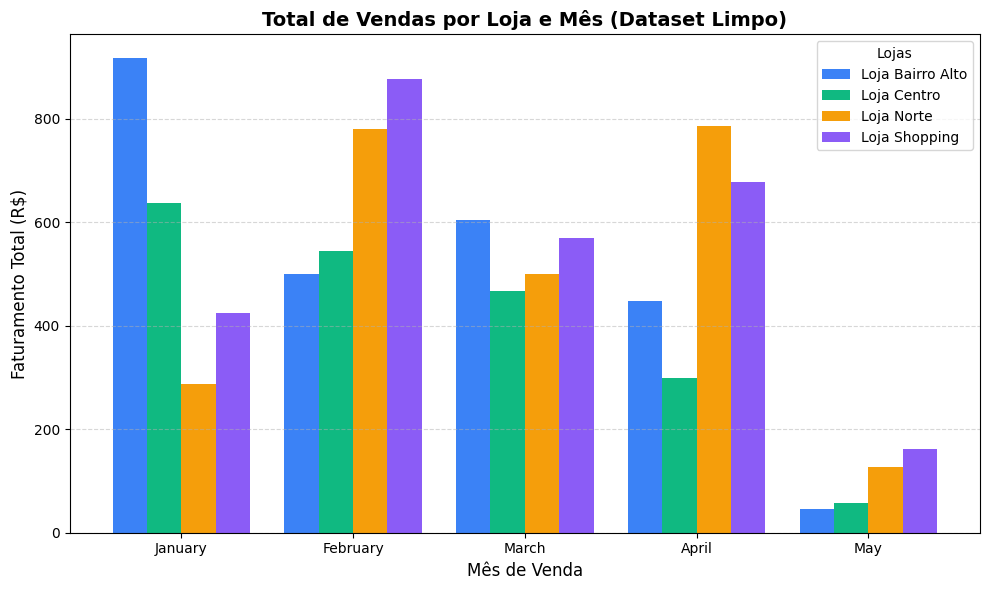

In [10]:
grafico_data = resultado_metas.pivot(index='Mes_Nome', columns='Loja', values='Total_Vendido')

meses_ordenados = ['January', 'February', 'March', 'April', 'May']
grafico_data = grafico_data.reindex(meses_ordenados)

grafico_data.plot(kind='bar', figsize=(10, 6), width=0.8, color=['#3b82f6', '#10b981', '#f59e0b', '#8b5cf6'])

plt.title('Total de Vendas por Loja e Mês (Dataset Limpo)', fontsize=14, fontweight='bold')
plt.xlabel('Mês de Venda', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Lojas')
plt.tight_layout()
plt.show()